First 5 rows of the dataset:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset Shape:
(768, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnanc

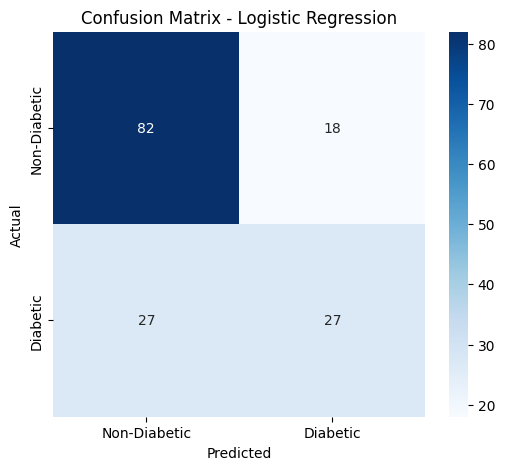


KNN Confusion Matrix:
[[83 17]
 [21 33]]


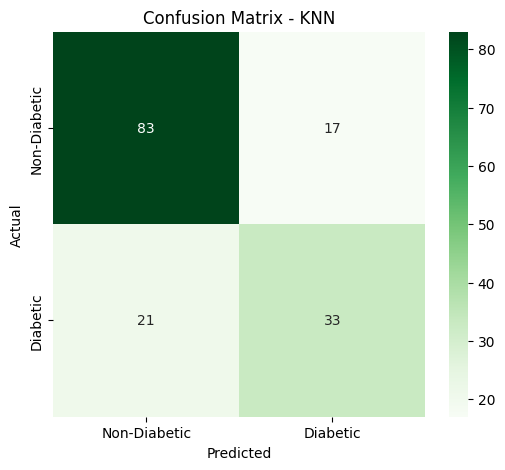


Decision Tree Confusion Matrix:
[[78 22]
 [15 39]]


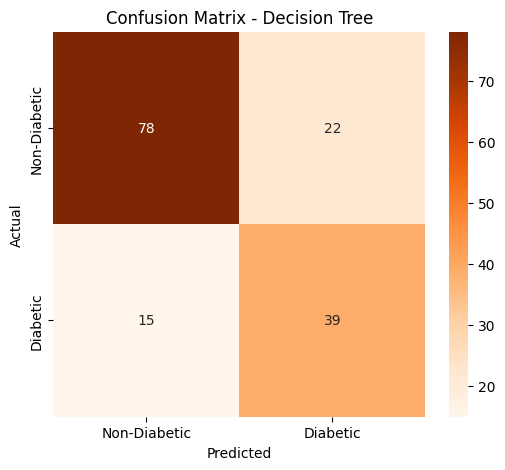

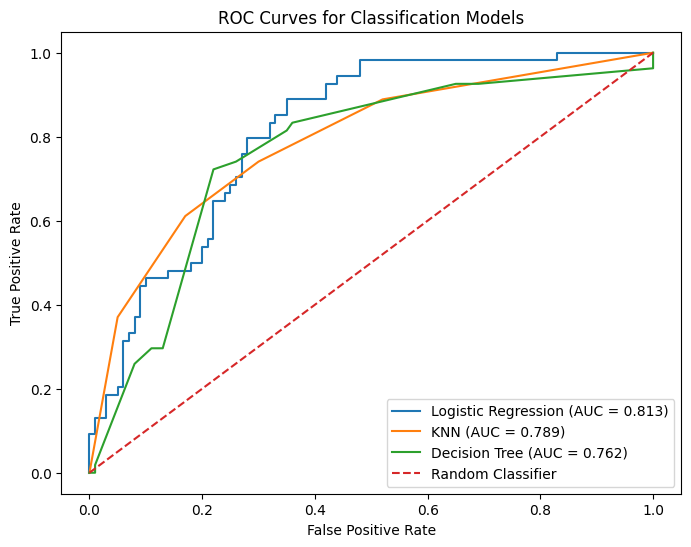

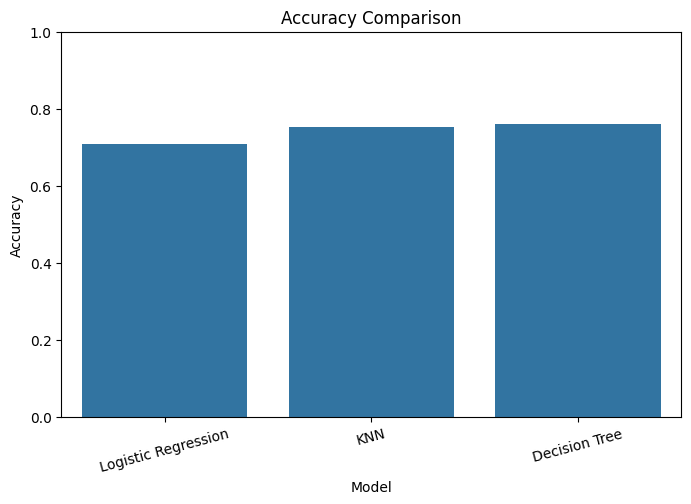


EXPERIMENT COMPLETED SUCCESSFULLY

Final Model Performance:
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.7078     0.6000  0.5000    0.5455   0.8130
1                  KNN    0.7532     0.6600  0.6111    0.6346   0.7886
2        Decision Tree    0.7597     0.6393  0.7222    0.6783   0.7622


In [3]:
# ============================================================
# EXPERIMENT 7
# Build and Evaluate Classification Models using
# Supervised Learning Algorithms
# Dataset: Pima Indians Diabetes Dataset
# ============================================================

# ------------------------------------------------------------
# 1. Import required libraries
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# ------------------------------------------------------------
# 2. Load the dataset
# ------------------------------------------------------------

# Make sure diabetes.csv is uploaded to Google Colab/Jupyter

df = pd.read_csv("diabetes.csv")

print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 3. Display dataset information
# ------------------------------------------------------------

print("\nDataset Information:")
df.info()

# ------------------------------------------------------------
# 4. Check missing values
# ------------------------------------------------------------

print("\nMissing values:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 5. Display descriptive statistics
# ------------------------------------------------------------

print("\nDescriptive Statistics:")
print(df.describe())

# ------------------------------------------------------------
# 6. Handle invalid zero values
# ------------------------------------------------------------

# In the Pima dataset, zero values in these medical columns
# are generally considered invalid/missing observations.

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

# Replace zero values with NaN
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

print("\nMissing values after replacing invalid zeros:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 7. Fill missing values using median
# ------------------------------------------------------------

for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# ------------------------------------------------------------
# 8. Separate features and target
# ------------------------------------------------------------

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Variable: Outcome")

# ------------------------------------------------------------
# 9. Train-test split using stratification
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data size:", X_train.shape)
print("Testing data size:", X_test.shape)

# ------------------------------------------------------------
# 10. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ------------------------------------------------------------
# 11. Create classification models
# ------------------------------------------------------------

logistic_model = LogisticRegression(max_iter=1000)

knn_model = KNeighborsClassifier(n_neighbors=5)

decision_tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# ------------------------------------------------------------
# 12. Train Logistic Regression
# ------------------------------------------------------------

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)

logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 13. Train KNN
# ------------------------------------------------------------

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

# ------------------------------------------------------------
# 14. Train Decision Tree
# ------------------------------------------------------------

decision_tree_model.fit(X_train, y_train)

tree_pred = decision_tree_model.predict(X_test)

tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------------------
# 15. Function to calculate evaluation metrics
# ------------------------------------------------------------

def evaluate_model(name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("\n==========================================")
    print(name)
    print("==========================================")

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1-Score :", round(f1, 4))
    print("ROC-AUC  :", round(auc, 4))

    print("\nClassification Report:")
    print(
        classification_report(
            y_true,
            y_pred,
            target_names=["Non-Diabetic", "Diabetic"],
            zero_division=0
        )
    )

    return accuracy, precision, recall, f1, auc


# ------------------------------------------------------------
# 16. Evaluate Logistic Regression
# ------------------------------------------------------------

logistic_metrics = evaluate_model(
    "LOGISTIC REGRESSION",
    y_test,
    logistic_pred,
    logistic_prob
)

# ------------------------------------------------------------
# 17. Evaluate KNN
# ------------------------------------------------------------

knn_metrics = evaluate_model(
    "K-NEAREST NEIGHBORS",
    y_test,
    knn_pred,
    knn_prob
)

# ------------------------------------------------------------
# 18. Evaluate Decision Tree
# ------------------------------------------------------------

tree_metrics = evaluate_model(
    "DECISION TREE",
    y_test,
    tree_pred,
    tree_prob
)

# ------------------------------------------------------------
# 19. Create model comparison table
# ------------------------------------------------------------

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree"
    ],

    "Accuracy": [
        logistic_metrics[0],
        knn_metrics[0],
        tree_metrics[0]
    ],

    "Precision": [
        logistic_metrics[1],
        knn_metrics[1],
        tree_metrics[1]
    ],

    "Recall": [
        logistic_metrics[2],
        knn_metrics[2],
        tree_metrics[2]
    ],

    "F1-Score": [
        logistic_metrics[3],
        knn_metrics[3],
        tree_metrics[3]
    ],

    "ROC-AUC": [
        logistic_metrics[4],
        knn_metrics[4],
        tree_metrics[4]
    ]
})

print("\n==========================================")
print("MODEL COMPARISON")
print("==========================================")

print(results.round(4))

# ------------------------------------------------------------
# 20. Confusion Matrix - Logistic Regression
# ------------------------------------------------------------

cm_logistic = confusion_matrix(
    y_test,
    logistic_pred
)

print("\nLogistic Regression Confusion Matrix:")
print(cm_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

# ------------------------------------------------------------
# 21. Confusion Matrix - KNN
# ------------------------------------------------------------

cm_knn = confusion_matrix(
    y_test,
    knn_pred
)

print("\nKNN Confusion Matrix:")
print(cm_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - KNN")

plt.show()

# ------------------------------------------------------------
# 22. Confusion Matrix - Decision Tree
# ------------------------------------------------------------

cm_tree = confusion_matrix(
    y_test,
    tree_pred
)

print("\nDecision Tree Confusion Matrix:")
print(cm_tree)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Non-Diabetic", "Diabetic"],
    yticklabels=["Non-Diabetic", "Diabetic"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

# ------------------------------------------------------------
# 23. ROC Curves
# ------------------------------------------------------------

fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    logistic_prob
)

fpr_knn, tpr_knn, _ = roc_curve(
    y_test,
    knn_prob
)

fpr_tree, tpr_tree, _ = roc_curve(
    y_test,
    tree_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic Regression (AUC = {logistic_metrics[4]:.3f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {knn_metrics[4]:.3f})"
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f"Decision Tree (AUC = {tree_metrics[4]:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")

plt.legend()

plt.show()

# ------------------------------------------------------------
# 24. Accuracy comparison graph
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.title("Accuracy Comparison")

plt.xticks(rotation=15)

plt.show()

# ------------------------------------------------------------
# 25. Final output
# ------------------------------------------------------------

print("\n==========================================")
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("==========================================")

print("\nFinal Model Performance:")
print(results.round(4))